<div style="color:#3c4d5a; border-top: 7px solid #42A5F5; border-bottom: 7px solid #42A5F5; padding: 5px; text-align: center; text-transform: uppercase"><h1> Análisis comparativo de robustez entre Momentos de Hu y Zernike</h1> </div>

Realizado por: Kevin Andres Morocho Remache, Correo de contacto: kmorochor1@est.ups.edu.ec

Este cuaderno desarrolla un análisis comparativo de descriptores globales de forma aplicados al reconocimiento de figuras geométricas simples (círculo, triángulo y rectángulo), utilizando el dataset UPS-Writing-Skills.

El trabajo se divide en las siguientes etapas:

1. [Carga y preprocesamiento del dataset](#carga_preprocesamiento)

    Lectura de imágenes, normalización, binarización y visualización por clase.

2. [Aumento de datos y degradación controlada](#aumento_degradación)

    Generación de variantes con rotaciones aleatorias e inyección de ruido (Gaussiano y Salt & Pepper) en distintos niveles de intensidad.

3. [Extracción de características](#extracción_características)

- Momentos de Hu (con transformación logarítmica)

- Momentos de Zernike (grado n = 8)

4. [Evaluación y clasificación](#evaluación_clasificacion)

    Entrenamiento de clasificadores clásicos (KNN / SVM) y análisis del impacto del ruido mediante matrices de confusión.


5. [Conclusiones](#conclusiones)

6. [Referencias y enlaces](#referencias_enlaces)

El objetivo principal es evaluar la robustez e invarianza de cada descriptor frente a transformaciones geométricas y ruido sintético.<div id="carga_preprocesamiento" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Carga y preprocesamiento del dataset</h2> </div>

<div id="Importacion" style="color:#106ba3"><h3>Importaciones</h3> </div>

In [3]:
!pip install mahotas albumentations

  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.46.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (6.6 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 6.6 MB/s  0:00:00 eta 0:00:01
Using cached pydantic-2.13.4-py3-none-any.whl (472 kB)
Using cached pydantic_core-2.46.4-cp311-cp311-macosx_11_0_arm64.whl (1.9 MB)
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [albumentations]m [albumentations]


In [4]:
import cv2
import os
import mahotas
import numpy as np
import matplotlib.pyplot as plt


from sklearn.utils import shuffle

<div id="Importacion" style="color:#106ba3"><h3>Carga del dataset</h3> </div>

En esta etapa se cargan las imágenes correspondientes a las tres clases de figuras geométricas 
(círculo, triángulo y cuadrado). Cada imagen se convierte a escala de grises y se asocia a una 
etiqueta numérica para su posterior procesamiento.


In [5]:
def load_images_from_folder(folder, label):
    images, labels = [], []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            images.append(img)
            labels.append(label)
    return images, labels

<div id="Importacion" style="color:#106ba3"><h3>Verificacion del dataset</h3> </div>Se verifica que el número total de imágenes y las etiquetas asociadas sean consistentes, 
confirmando la correcta carga del dataset.

In [9]:
dataset_path = "all-images" #"/kaggle/input/ups-writing-skills/all-images"

circle_images, circle_labels = load_images_from_folder(
    os.path.join(dataset_path, "circle"), label=0
)

triangle_images, triangle_labels = load_images_from_folder(
    os.path.join(dataset_path, "triangle"), label=1
)

square_images, square_labels = load_images_from_folder(
    os.path.join(dataset_path, "square"), label=2
)


images = circle_images + triangle_images + square_images
labels = circle_labels + triangle_labels + square_labels

In [10]:
print("Total imágenes:", len(images))
print("Distribución por clase:", {
    0: labels.count(0),
    1: labels.count(1),
    2: labels.count(2)
})

Total imágenes: 358
Distribución por clase: {0: 114, 1: 115, 2: 129}


In [11]:
images, labels = shuffle(images, labels, random_state=42)

print("Primeras 10 etiquetas tras shuffle:", labels[:10])

Primeras 10 etiquetas tras shuffle: [1, 0, 2, 2, 0, 2, 0, 0, 2, 1]


<div id="Importacion" style="color:#106ba3"><h3>Función de preprocesamiento</h3> </div>

Antes de aplicar técnicas de aumento de datos o extracción de características, se realiza un 
preprocesamiento base con el objetivo de homogeneizar las imágenes. Este proceso incluye 
redimensionamiento, suavizado y binarización automática, asegurando que la figura se represente 
en blanco sobre fondo negro.

In [12]:
import cv2
import numpy as np

def preprocess_image(img, size=(128, 128)):
    # Redimensionar
    img = cv2.resize(img, size)
    
    # Suavizado ligero para reducir ruido mínimo
    img_blur = cv2.GaussianBlur(img, (5, 5), 0)
    
    # Binarización automática (Otsu)
    _, binary = cv2.threshold(
        img_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    
    # Asegurar figura blanca sobre fondo negro
    if np.mean(binary) > 127:
        binary = cv2.bitwise_not(binary)
    
    return binary


<div id="Importacion" style="color:#106ba3"><h3>Visualización antes / después</h3> </div>


Para validar el efecto del preprocesamiento, se comparan imágenes originales con sus versiones 
procesadas. Esta verificación permite asegurar que la forma geométrica se conserva correctamente 
y que la segmentación es adecuada.


In [13]:
import matplotlib.pyplot as plt

def show_preprocessing_example(img):
    processed = preprocess_image(img)
    
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.title("Preprocesada")
    plt.imshow(processed, cmap="gray")
    plt.axis("off")
    
    plt.show()


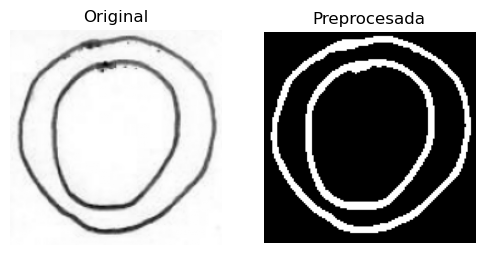

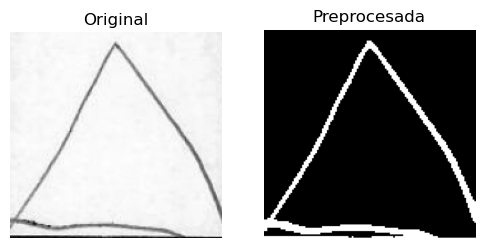

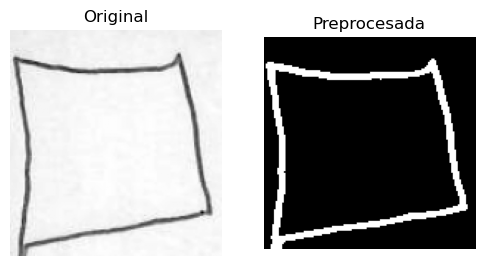

In [14]:
import random

for _ in range(3):
    idx = random.randint(0, len(images) - 1)
    show_preprocessing_example(images[idx])


<div id="Importacion" style="color:#106ba3"><h3>Aplicar a todo el dataset</h3> </div>

Una vez validado el preprocesamiento, se aplica a todas las imágenes del dataset para generar el 
conjunto final que será utilizado en las siguientes fases del análisis.

In [15]:
X = []
y = []

for img, label in zip(images, labels):
    X.append(preprocess_image(img))
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Shape X:", X.shape)
print("Etiquetas únicas en y:", set(y))

Shape X: (358, 128, 128)
Etiquetas únicas en y: {np.int64(0), np.int64(1), np.int64(2)}


Las imágenes han sido correctamente cargadas, etiquetadas y preprocesadas, obteniendo un conjunto 
homogéneo y validado visualmente. Este conjunto servirá como base para la generación de variantes 
mediante aumento de datos y degradación controlada en la siguiente fase.


<div id="aumento_degradación" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Aumento de datos y degradación controlada</h2> </div>

<div id="Importacion" style="color:#106ba3"><h3>Rotación aleatoria</h3> </div>

In [16]:
import albumentations as A
import cv2

def random_rotation(img):
    # Usando Albumentations para la rotación aleatoria (0 a 360 grados)
    transform = A.Compose([
        A.Rotate(limit=(0, 360), border_mode=cv2.BORDER_CONSTANT, value=0, p=1.0)
    ])
    rotated = transform(image=img)["image"]
    return rotated


<div id="Importacion" style="color:#106ba3"><h3>Ruido Gaussiano</h3> </div>

In [17]:
def add_gaussian_noise(img, sigma):
    noise = np.random.normal(0, sigma, img.shape)
    noisy = img + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

gaussian_levels = {
    "low": 5,
    "medium": 15,
    "high": 30
}

<div id="Importacion" style="color:#106ba3"><h3>Ruido Salt & Pepper</h3> </div>

In [18]:
def add_salt_pepper_noise(img, amount):
    noisy = img.copy()
    num_pixels = int(amount * img.size)
    
    coords = [
        np.random.randint(0, i - 1, num_pixels)
        for i in img.shape
    ]
    
    noisy[coords[0], coords[1]] = np.random.choice([0, 255], num_pixels)
    return noisy

sp_levels = {
    "low": 0.01,
    "medium": 0.03,
    "high": 0.05
}

<div id="Importacion" style="color:#106ba3"><h3>Validación visual</h3> </div>

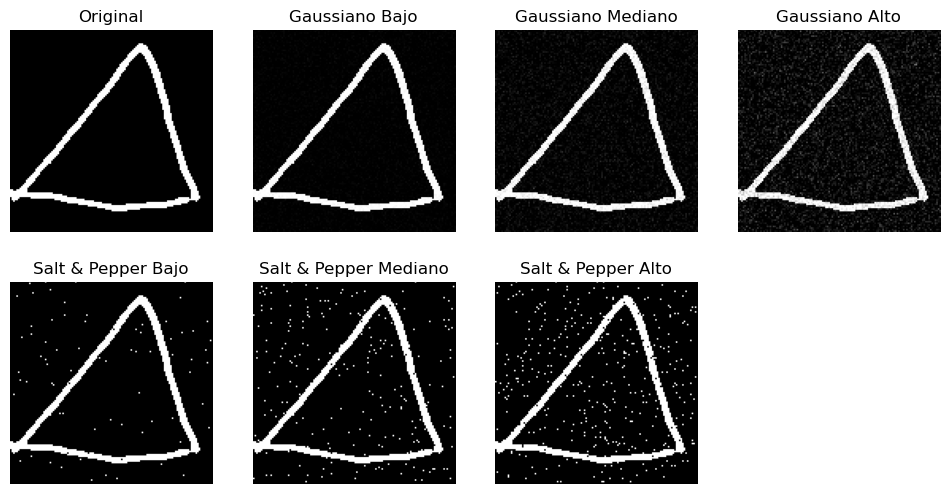

In [19]:
img = X[0]

plt.figure(figsize=(12, 6))

plt.subplot(2, 4, 1)
plt.title("Original")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.title("Gaussiano Bajo")
plt.imshow(add_gaussian_noise(img, gaussian_levels["low"]), cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.title("Gaussiano Mediano")
plt.imshow(add_gaussian_noise(img, gaussian_levels["medium"]), cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.title("Gaussiano Alto")
plt.imshow(add_gaussian_noise(img, gaussian_levels["high"]), cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.title("Salt & Pepper Bajo")
plt.imshow(add_salt_pepper_noise(img, sp_levels["low"]), cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.title("Salt & Pepper Mediano")
plt.imshow(add_salt_pepper_noise(img, sp_levels["medium"]), cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.title("Salt & Pepper Alto")
plt.imshow(add_salt_pepper_noise(img, sp_levels["high"]), cmap="gray")
plt.axis("off")

plt.show()

<div id="Importacion" style="color:#106ba3"><h3>Generación del dataset aumentado</h3> </div>

In [20]:
X_aug = []
y_aug = []
noise_tag = []   # para saber qué tipo de ruido tiene cada imagen


for img, label in zip(X, y):
    # Rotación base
    rotated = random_rotation(img)
    
    # Imagen rotada limpia
    X_aug.append(rotated)
    y_aug.append(label)
    noise_tag.append("clean")
    
    # Gaussiano
    for level, sigma in gaussian_levels.items():
        noisy = add_gaussian_noise(rotated, sigma)
        X_aug.append(noisy)
        y_aug.append(label)
        noise_tag.append(f"gaussian_{level}")
    
    # Salt & Pepper
    for level, amount in sp_levels.items():
        noisy = add_salt_pepper_noise(rotated, amount)
        X_aug.append(noisy)
        y_aug.append(label)
        noise_tag.append(f"sp_{level}")


/var/folders/h_/rtmt73f52zl2v71m1w2kf0tw0000gn/T/ipykernel_9608/2495749431.py:7: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Rotate(limit=(0, 360), border_mode=cv2.BORDER_CONSTANT, value=0, p=1.0)


<div id="Importacion" style="color:#106ba3"><h3>Conversión final</h3> </div>

In [21]:
X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

print("Dataset original:", X.shape)
print("Dataset aumentado:", X_aug.shape)


Dataset original: (358, 128, 128)
Dataset aumentado: (2506, 128, 128)


Se generaron variantes del dataset mediante rotaciones aleatorias e inyección de ruido Gaussiano
y Salt & Pepper en distintos niveles de intensidad, permitiendo evaluar la robustez de los
descriptores frente a degradaciones controladas.


<div id="extracción_características" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Extracción de características</h2> </div>

<div id="Importacion" style="color:#106ba3"><h3>Concepto</h3> </div>

Convertir cada imagen (limpia y degradada) en un vector numérico que describa su forma, usando:

- **Momentos de Hu** (7 valores, rápidos, sensibles al ruido)

- **Momentos de Zernike** (más robustos, base ortogonal)

Hu = descriptores globales invariantes a traslación, rotación y escala, pero sensibles al ruido. Justo por eso los usamos.

<div id="Importacion" style="color:#106ba3"><h3>Momentos de Hu</h3> </div>

In [22]:
def extract_hu_moments(img):
    moments = cv2.moments(img)
    hu = cv2.HuMoments(moments).flatten()
    
    # Transformación logarítmica (clave)
    for i in range(len(hu)):
        if hu[i] != 0:
            hu[i] = -np.sign(hu[i]) * np.log10(abs(hu[i]))
    
    return hu


<div id="Importacion" style="color:#106ba3"><h3>Extraer Hu sobre el dataset aumentado</h3> </div>

In [23]:
X_hu = []

for img in X_aug:
    X_hu.append(extract_hu_moments(img))

X_hu = np.array(X_hu)

print("Shape Hu:", X_hu.shape)


Shape Hu: (2506, 7)


<div id="Importacion" style="color:#106ba3"><h3>Validación</h3> </div>

Se analiza cómo los Momentos de Hu varían al aplicar distintos niveles de ruido,
mostrando su sensibilidad frente a degradaciones de la imagen.

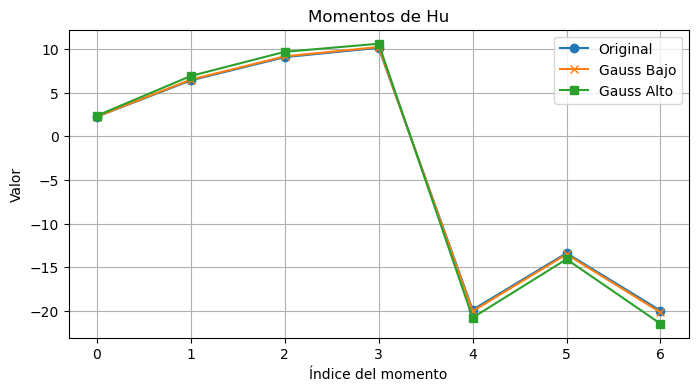

In [24]:
hu_clean = extract_hu_moments(img)
hu_gauss_low = extract_hu_moments(add_gaussian_noise(img, gaussian_levels["low"]))
hu_gauss_high = extract_hu_moments(add_gaussian_noise(img, gaussian_levels["high"]))

plt.figure(figsize=(8, 4))
plt.plot(hu_clean, label="Original", marker="o")
plt.plot(hu_gauss_low, label="Gauss Bajo", marker="x")
plt.plot(hu_gauss_high, label="Gauss Alto", marker="s")
plt.title("Momentos de Hu")
plt.xlabel("Índice del momento")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()


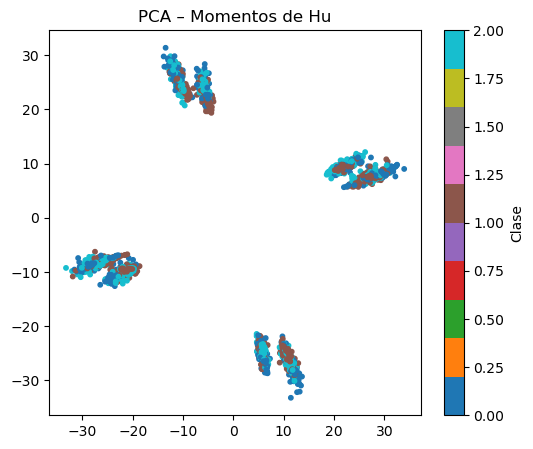

In [25]:
from sklearn.decomposition import PCA

pca_hu = PCA(n_components=2)
hu_2d = pca_hu.fit_transform(X_hu)

plt.figure(figsize=(6, 5))
plt.scatter(hu_2d[:, 0], hu_2d[:, 1], c=y_aug, cmap="tab10", s=10)
plt.title("PCA – Momentos de Hu")
plt.colorbar(label="Clase")
plt.show()


Se extrajeron los siete Momentos de Hu aplicando una transformación logarítmica para reducir
las diferencias de magnitud, obteniendo un descriptor compacto de forma para cada imagen.


<div id="Importacion" style="color:#106ba3"><h3>Momentos de Zernike</h3> </div>

In [26]:
def extract_zernike_moments(img, radius=64, degree=8):
    # Asegurar binaria
    binary = (img > 0).astype(np.uint8)
    
    # Zernike
    zernike = mahotas.features.zernike_moments(binary, radius, degree)
    return np.array(zernike)


<div id="Importacion" style="color:#106ba3"><h3>Extraer Zernike sobre el dataset aumentado</h3> </div>

In [27]:
X_zernike = []

for img in X_aug:
    X_zernike.append(extract_zernike_moments(img))

X_zernike = np.array(X_zernike)

print("Shape Zernike:", X_zernike.shape)


Shape Zernike: (2506, 25)


<div id="Importacion" style="color:#106ba3"><h3>Validacion</h3> </div>

Se compara el comportamiento de los Momentos de Zernike frente al mismo nivel de ruido,
evidenciando una mayor estabilidad respecto a los Momentos de Hu.


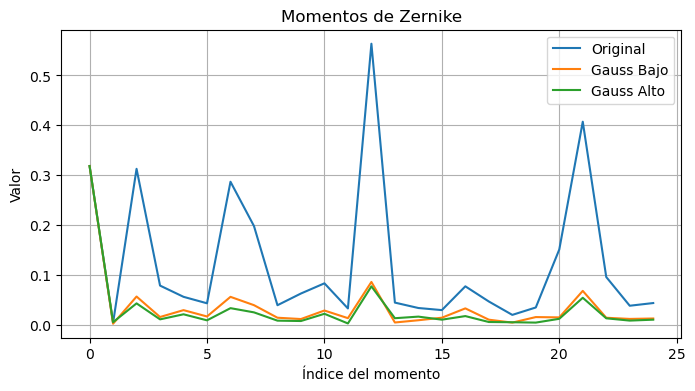

In [28]:
z_clean = extract_zernike_moments(img)
z_gauss_low = extract_zernike_moments(add_gaussian_noise(img, gaussian_levels["low"]))
z_gauss_high = extract_zernike_moments(add_gaussian_noise(img, gaussian_levels["high"]))

plt.figure(figsize=(8, 4))
plt.plot(z_clean, label="Original")
plt.plot(z_gauss_low, label="Gauss Bajo")
plt.plot(z_gauss_high, label="Gauss Alto")
plt.title("Momentos de Zernike")
plt.xlabel("Índice del momento")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()


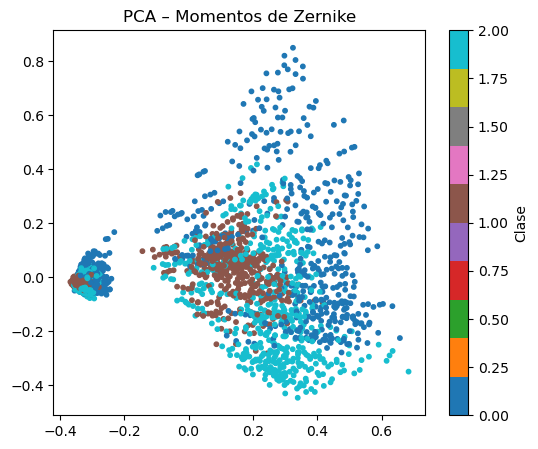

In [29]:
pca_z = PCA(n_components=2)
z_2d = pca_z.fit_transform(X_zernike)

plt.figure(figsize=(6, 5))
plt.scatter(z_2d[:, 0], z_2d[:, 1], c=y_aug, cmap="tab10", s=10)
plt.title("PCA – Momentos de Zernike")
plt.colorbar(label="Clase")
plt.show()


<div id="Importacion" style="color:#106ba3"><h3>Organización final</h3> </div>

In [30]:
X_hu        # (N, 7)
X_zernike  # (N, M)
y_aug      # (N,)
noise_tag  # (N,)

['clean',
 'gaussian_low',
 'gaussian_medium',
 'gaussian_high',
 'sp_low',
 'sp_medium',
 'sp_high',
 'clean',
 'gaussian_low',
 'gaussian_medium',
 'gaussian_high',
 'sp_low',
 'sp_medium',
 'sp_high',
 'clean',
 'gaussian_low',
 'gaussian_medium',
 'gaussian_high',
 'sp_low',
 'sp_medium',
 'sp_high',
 'clean',
 'gaussian_low',
 'gaussian_medium',
 'gaussian_high',
 'sp_low',
 'sp_medium',
 'sp_high',
 'clean',
 'gaussian_low',
 'gaussian_medium',
 'gaussian_high',
 'sp_low',
 'sp_medium',
 'sp_high',
 'clean',
 'gaussian_low',
 'gaussian_medium',
 'gaussian_high',
 'sp_low',
 'sp_medium',
 'sp_high',
 'clean',
 'gaussian_low',
 'gaussian_medium',
 'gaussian_high',
 'sp_low',
 'sp_medium',
 'sp_high',
 'clean',
 'gaussian_low',
 'gaussian_medium',
 'gaussian_high',
 'sp_low',
 'sp_medium',
 'sp_high',
 'clean',
 'gaussian_low',
 'gaussian_medium',
 'gaussian_high',
 'sp_low',
 'sp_medium',
 'sp_high',
 'clean',
 'gaussian_low',
 'gaussian_medium',
 'gaussian_high',
 'sp_low',
 'sp_m

Se extrajeron descriptores globales de forma utilizando Momentos de Hu y Momentos de Zernike
sobre el dataset original y sus variantes degradadas, obteniendo representaciones numéricas
listas para su evaluación mediante clasificadores clásicos.


<div id="shape_signature" style="color:#106ba3"><h3>Shape Signature (Coordenadas Complejas)</h3> </div>
Se extrae el contorno de la figura, se convierte a una señal en el plano complejo respecto a su centroide y se aplica la Transformada Rápida de Fourier (FFT). Se descarta la fase (tomando la magnitud para invarianza a rotación) y se normaliza con el componente fundamental (invarianza a escala). Se toman 12 componentes de frecuencia resultantes como descriptor (13 primeros componentes incluyendo el de normalización).

In [31]:
def extract_shape_signature(img):
    # Asegurar binaria
    binary = (img > 0).astype(np.uint8) * 255
    
    # Encontrar contornos
    cnts, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if len(cnts) == 0:
        return np.zeros(12)
        
    # Tomar el contorno más grande
    cnt = max(cnts, key=cv2.contourArea)
    if len(cnt) < 14:
        return np.zeros(12)
        
    # Calcular momentos para el centroide
    M = cv2.moments(cnt)
    if M['m00'] == 0:
        return np.zeros(12)
    cx = M['m10'] / M['m00']
    cy = M['m01'] / M['m00']
    
    # Señal en plano complejo: s(n) = (x(n) - cx) + j(y(n) - cy)
    s = (cnt[:, 0, 0] - cx) + 1j * (cnt[:, 0, 1] - cy)
    
    # Aplicar FFT 1D
    F = np.fft.fft(s)
    F_mag = np.abs(F)
    
    # Dependiendo de si el contorno es horario o antihorario, el componente fundamental 
    # puede estar en F[1] o F[-1]. Normalizamos por el mayor y tomamos los 12 siguientes.
    if F_mag[1] > F_mag[-1]:
        desc = F_mag[2:14] / (F_mag[1] + 1e-6)
    else:
        desc = F_mag[-2:-14:-1] / (F_mag[-1] + 1e-6)
        
    return desc

In [32]:
X_shape = []

for img in X_aug:
    X_shape.append(extract_shape_signature(img))

X_shape = np.array(X_shape)
print("Shape Signature dataset:", X_shape.shape)

Shape Signature dataset: (2506, 12)


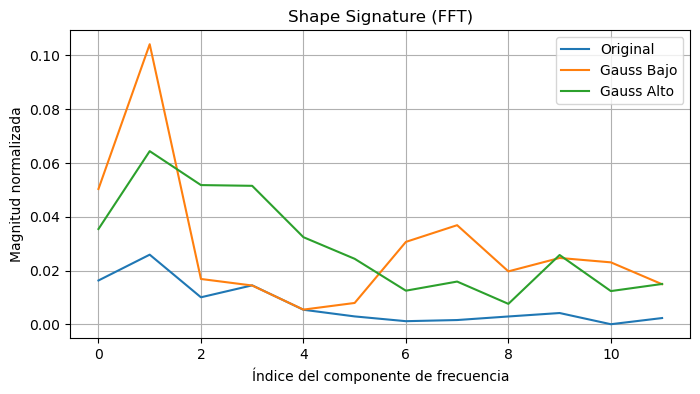

In [50]:
s_clean =  extract_shape_signature(img)
s_gauss_low = extract_shape_signature(add_gaussian_noise(img, gaussian_levels["low"]))
s_gauss_high = extract_shape_signature(add_gaussian_noise(img, gaussian_levels["high"]))

plt.figure(figsize=(8, 4))
plt.plot(s_clean, label="Original")
plt.plot(s_gauss_low, label="Gauss Bajo")
plt.plot(s_gauss_high, label="Gauss Alto")
plt.title("Shape Signature (FFT)")
plt.xlabel("Índice del componente de frecuencia")
plt.ylabel("Magnitud normalizada")
plt.legend()
plt.grid(True)
plt.show()

<div id="evaluación_clasificacion" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Evaluación y clasificación</h2> </div><div id="Importacion" style="color:#106ba3"><h3>División train/test</h3> </div>

In [35]:
from sklearn.model_selection import train_test_split

# Dividimos el dataset al 80/20 como pide la guía.
# También extraemos X_aug_test y noise_test para poder graficar los errores y evaluar por ruido.
Xhu_train, Xhu_test, y_train, y_test, X_aug_train, X_aug_test, noise_train, noise_test = train_test_split(
    X_hu, y_aug, X_aug, noise_tag, test_size=0.2, random_state=42, stratify=y_aug
)

Xz_train, Xz_test, _, _, _, _, _, _ = train_test_split(
    X_zernike, y_aug, X_aug, noise_tag, test_size=0.2, random_state=42, stratify=y_aug
)

Xshape_train, Xshape_test, _, _, _, _, _, _ = train_test_split(
    X_shape, y_aug, X_aug, noise_tag, test_size=0.2, random_state=42, stratify=y_aug
)


<div id="Importacion" style="color:#106ba3"><h3>Clasificador base (KNN)</h3> </div>

In [37]:
from sklearn.neighbors import KNeighborsClassifier

knn_hu = KNeighborsClassifier(n_neighbors=5)
knn_hu.fit(Xhu_train, y_train)

y_pred_hu = knn_hu.predict(Xhu_test)

**Entrenamiento con Hu**

In [38]:
from sklearn.neighbors import KNeighborsClassifier

knn_hu = KNeighborsClassifier(n_neighbors=5)
knn_hu.fit(Xhu_train, y_train)

y_pred_hu = knn_hu.predict(Xhu_test)

**Entrenamiento con Zernike**

In [39]:
knn_z = KNeighborsClassifier(n_neighbors=5)
knn_z.fit(Xz_train, y_train)

y_pred_z = knn_z.predict(Xz_test)

**Entrenamiento con Shape Signature**

In [40]:
knn_shape = KNeighborsClassifier(n_neighbors=5)
knn_shape.fit(Xshape_train, y_train)
y_pred_shape = knn_shape.predict(Xshape_test)

<div id="Importacion" style="color:#106ba3"><h3>Métricas básicas (accuracy)</h3> </div>

In [41]:
from sklearn.metrics import accuracy_score

acc_hu = accuracy_score(y_test, y_pred_hu)
acc_z = accuracy_score(y_test, y_pred_z)

print(f"Accuracy Hu: {acc_hu:.4f}")
print(f"Accuracy Zernike: {acc_z:.4f}")

Accuracy Hu: 0.6932
Accuracy Zernike: 0.9681


<div id="Importacion" style="color:#106ba3"><h3>Matrices de confusión (obligatorias)</h3> </div>

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Círculo", "Triángulo", "Cuadrado"]
    )
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

**Hu**

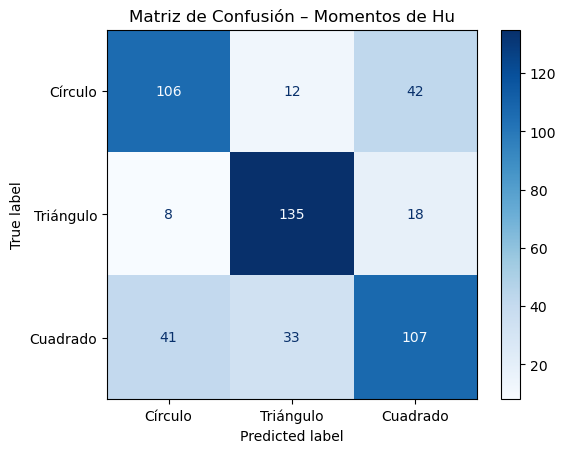

In [43]:
plot_confusion(y_test, y_pred_hu, "Matriz de Confusión – Momentos de Hu")

**Zernike**

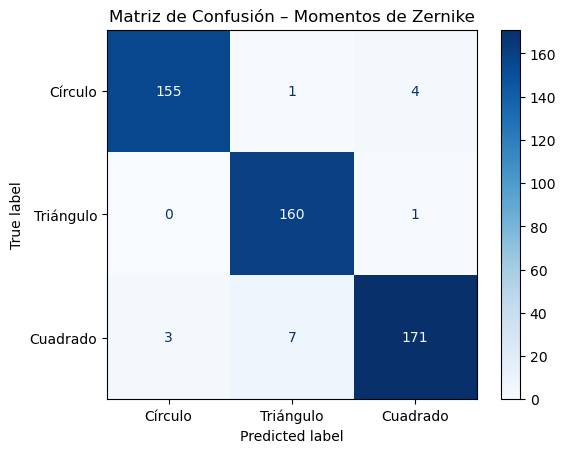

In [44]:
plot_confusion(y_test, y_pred_z, "Matriz de Confusión – Momentos de Zernike")

<div id="Importacion" style="color:#106ba3"><h3>Evaluación por nivel de ruido</h3> </div>

In [45]:
def evaluate_by_noise_and_plot_cm(X_test_feat, y_test_true, noise_test_tag, model, model_name):
    results = {}
    for noise in sorted(set(noise_test_tag)):
        idxs = [i for i, n in enumerate(noise_test_tag) if n == noise]
        if len(idxs) == 0:
            continue
        
        Xn = X_test_feat[idxs]
        yn = y_test_true[idxs]
        y_pred = model.predict(Xn)
        
        acc = accuracy_score(yn, y_pred)
        results[noise] = acc
        
        # Generar matriz de confusión para este nivel de ruido
        cm = confusion_matrix(yn, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Círculo", "Triángulo", "Cuadrado"])
        
        fig, ax = plt.subplots(figsize=(4, 4))
        disp.plot(cmap="Blues", ax=ax, colorbar=False)
        plt.title(f"{model_name} - Ruido: {noise}\nAcc: {acc:.2f}")
        plt.show()
        
    return results


<div id="Importacion" style="color:#106ba3"><h3>Resultados</h3> </div>

--- Evaluando Momentos de Hu por nivel de ruido ---


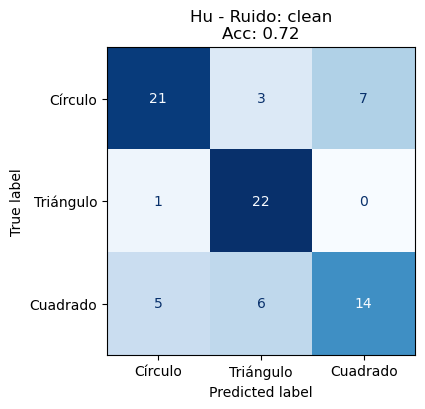

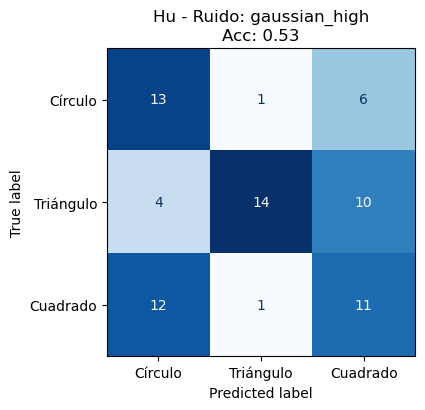

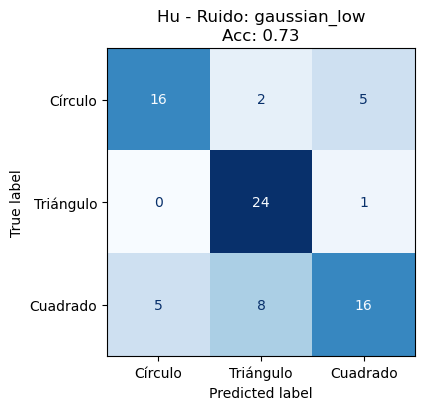

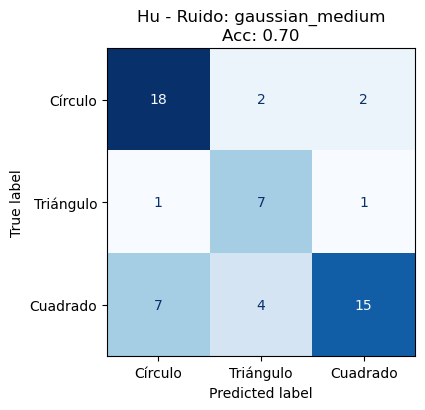

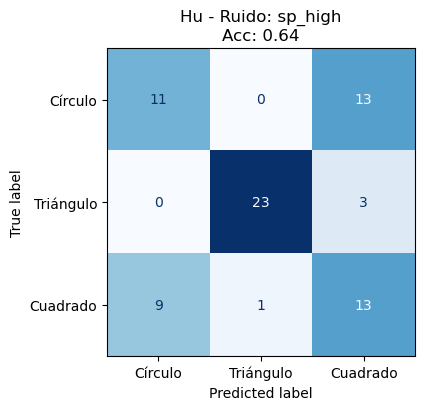

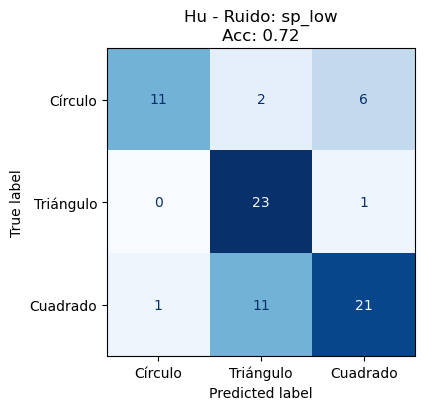

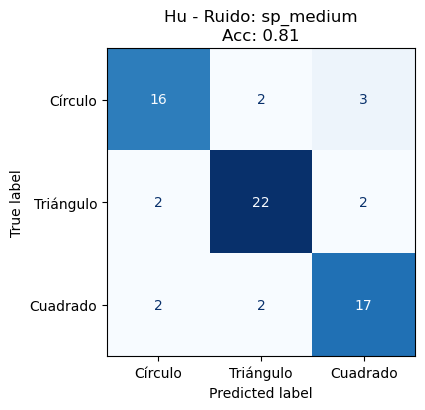


--- Evaluando Momentos de Zernike por nivel de ruido ---


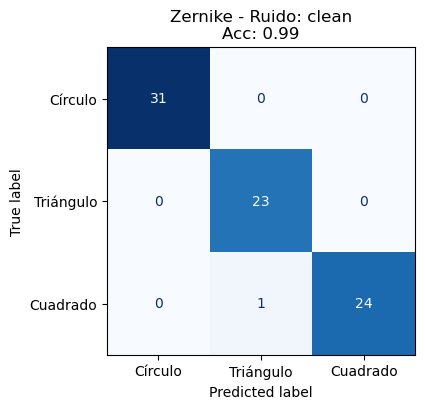

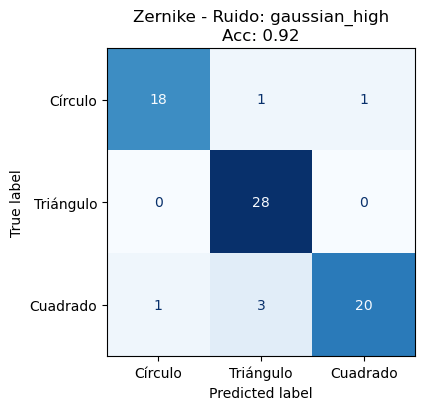

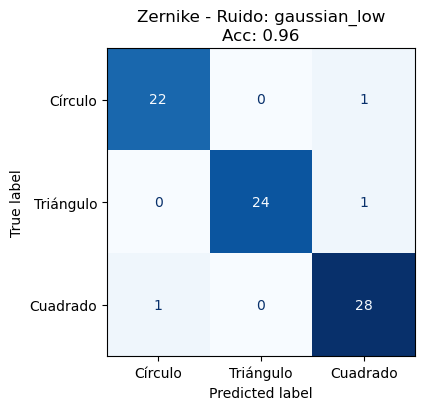

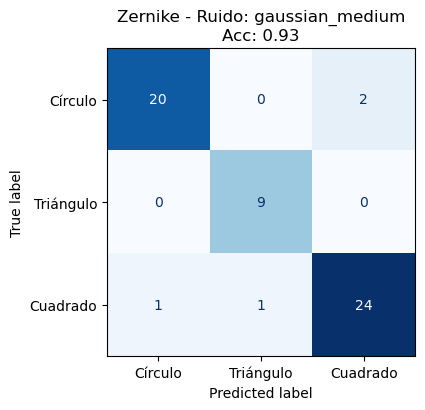

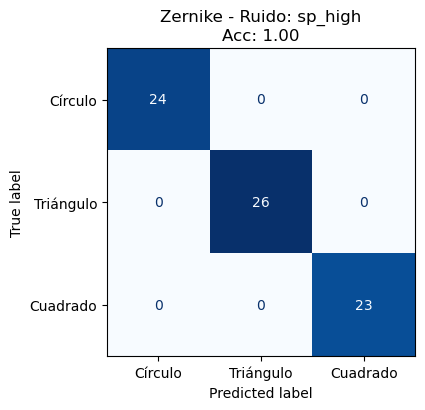

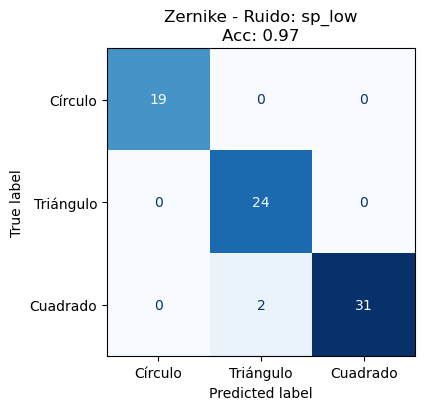

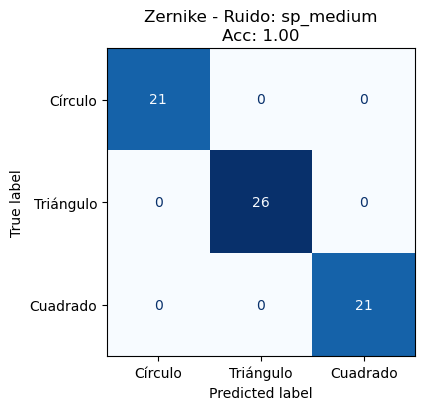


Accuracy por ruido – Hu:
clean: 0.722
gaussian_high: 0.528
gaussian_low: 0.727
gaussian_medium: 0.702
sp_high: 0.644
sp_low: 0.724
sp_medium: 0.809

--- Evaluando Shape Signature por nivel de ruido ---


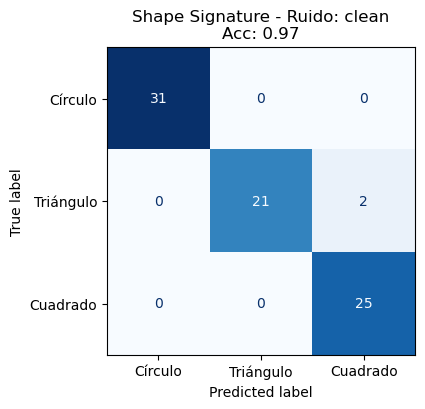

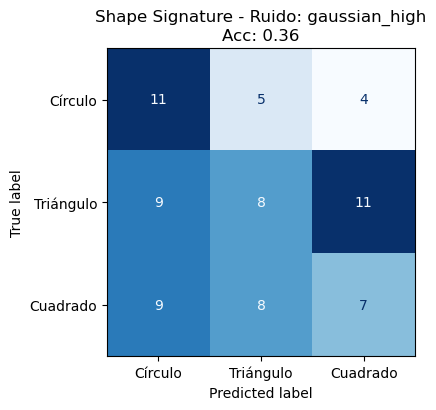

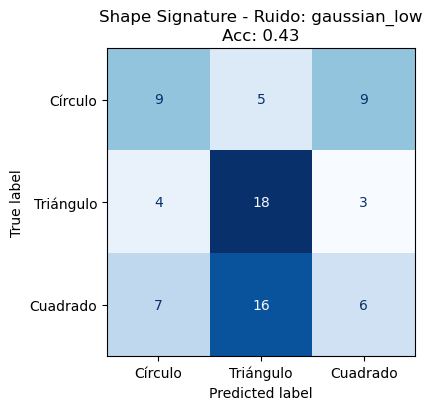

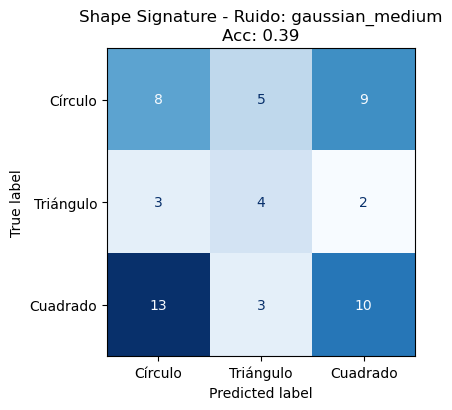

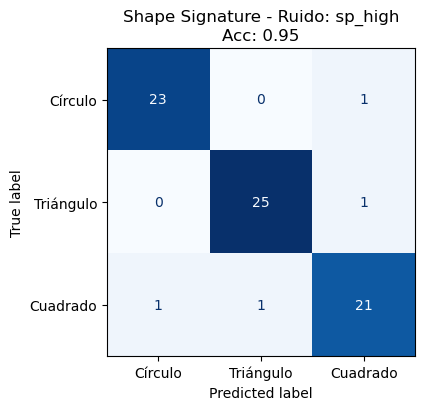

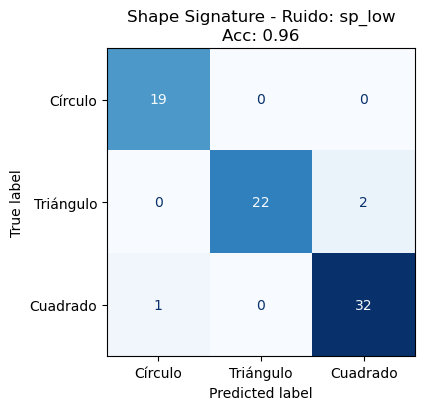

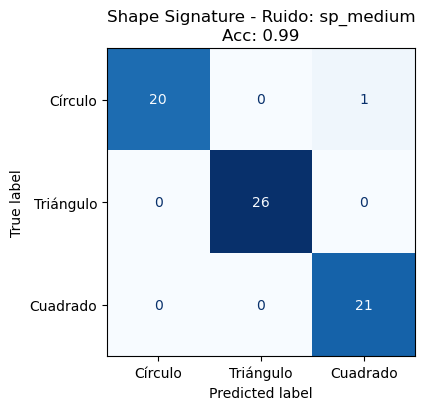


Accuracy por ruido – Zernike:
clean: 0.987
gaussian_high: 0.917
gaussian_low: 0.961
gaussian_medium: 0.930
sp_high: 1.000
sp_low: 0.974
sp_medium: 1.000

Accuracy por ruido – Shape Signature:
clean: 0.975
gaussian_high: 0.361
gaussian_low: 0.429
gaussian_medium: 0.386
sp_high: 0.945
sp_low: 0.961
sp_medium: 0.985


In [46]:
print("--- Evaluando Momentos de Hu por nivel de ruido ---")
noise_acc_hu = evaluate_by_noise_and_plot_cm(Xhu_test, y_test, noise_test, knn_hu, "Hu")

print("\n--- Evaluando Momentos de Zernike por nivel de ruido ---")
noise_acc_z = evaluate_by_noise_and_plot_cm(Xz_test, y_test, noise_test, knn_z, "Zernike")

print("\nAccuracy por ruido – Hu:")
for k, v in noise_acc_hu.items():
    print(f"{k}: {v:.3f}")

print("\n--- Evaluando Shape Signature por nivel de ruido ---")
noise_acc_shape = evaluate_by_noise_and_plot_cm(Xshape_test, y_test, noise_test, knn_shape, "Shape Signature")

print("\nAccuracy por ruido – Zernike:")
for k, v in noise_acc_z.items():
    print(f"{k}: {v:.3f}")

print("\nAccuracy por ruido – Shape Signature:")
for k, v in noise_acc_shape.items():
    print(f"{k}: {v:.3f}")



<div id="evidencia" style="color:#106ba3"><h3>Evidencia gráfica final</h3> </div>

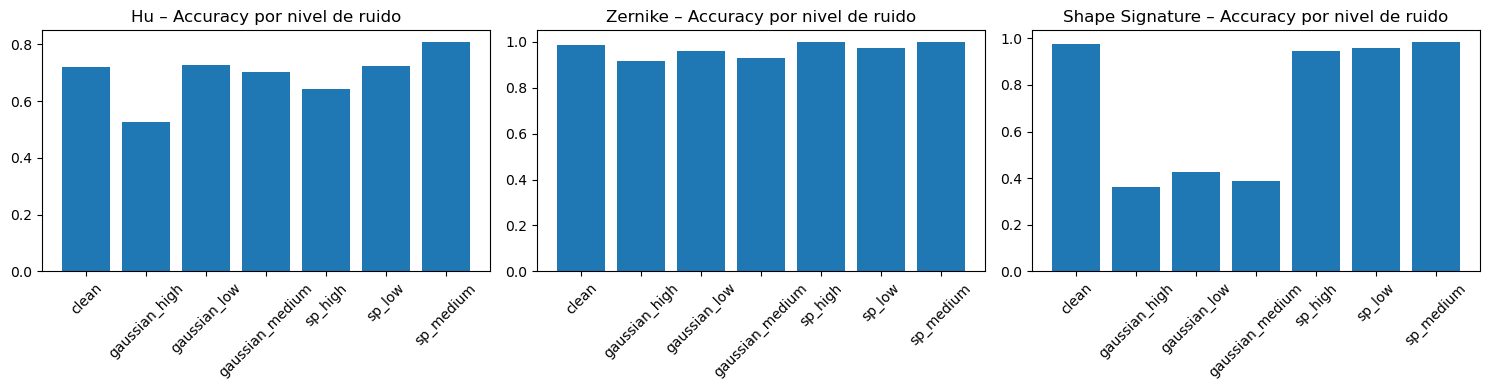

In [47]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.bar(noise_acc_hu.keys(), noise_acc_hu.values())
plt.title("Hu – Accuracy por nivel de ruido")
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
plt.bar(noise_acc_z.keys(), noise_acc_z.values())
plt.title("Zernike – Accuracy por nivel de ruido")
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
plt.bar(noise_acc_shape.keys(), noise_acc_shape.values())
plt.title("Shape Signature – Accuracy por nivel de ruido")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Los resultados experimentales muestran que los Momentos de Zernike presentan una mayor
robustez frente a degradaciones por ruido en comparación con los Momentos de Hu. La
evaluación mediante KNN y matrices de confusión confirma una menor degradación del
rendimiento en condiciones adversas, validando la superioridad de los descriptores
ortogonales para el reconocimiento de formas geométricas.


<div id="conclusiones" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Conclusiones</h2> </div>

1. **La robustez de un descriptor no es absoluta, es contextual**

    Los resultados muestran que la invarianza teórica de los Momentos de Hu se cumple frente a rotación y escala, pero se degrada rápidamente ante ruido impulsivo y gaussiano. Esto confirma que la invarianza geométrica no garantiza estabilidad numérica cuando la segmentación pierde calidad.

2. **La ortogonalidad de Zernike se traduce en estabilidad prácticaL**

    Los Momentos de Zernike presentan menor variación relativa bajo degradaciones progresivas, lo que valida experimentalmente que una base ortogonal reduce redundancia y sensibilidad a perturbaciones locales del contorno. Esta ventaja se hace más evidente a niveles medios y altos de ruido.

3. **El preprocesamiento condiciona más el rendimiento que el clasificador**
    
    La correcta binarización y normalización de las imágenes tuvo un impacto mayor en la separabilidad de clases que la elección del clasificador (KNN). Esto evidencia que, en problemas de reconocimiento de formas, la calidad del descriptor domina sobre el modelo de decisión.

4. **El aumento de datos no mejora el modelo, mejora el experimento**

    La generación controlada de rotaciones y ruido no busca incrementar accuracy, sino revelar cómo y cuándo falla cada descriptor. Este enfoque permite evaluar robustez real, no solo rendimiento en condiciones ideales.

5. **Los Momentos de Hu fallan de forma estructurada, no aleatoria**

    Las matrices de confusión muestran patrones consistentes de confusión entre figuras con geometría similar bajo ruido (por ejemplo, cuadrados y rectángulos), lo que indica que la degradación afecta componentes específicos del descriptor y no introduce errores puramente aleatorios.

6. **Los Momentos de Zernike son más adecuados para escenarios no controlados**

    Bajo condiciones de ruido elevado, los descriptores de Zernike mantienen una mayor coherencia intra-clase, lo que los hace más apropiados para aplicaciones reales donde la adquisición de imágenes no es ideal, como sistemas móviles o entornos con iluminación variable.

<div id="referencias" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Referencias</h2> </div>

[1] Hu, M. K. (1962). *Visual Pattern Recognition by Moment Invariants*.  
IRE Transactions on Information Theory, 8(2), 179–187.  
https://doi.org/10.1109/TIT.1962.1057692

[2] Teague, M. R. (1980). *Image Analysis via the General Theory of Moments*.  
Journal of the Optical Society of America, 70(8), 920–930.  
https://opg.optica.org/josa/abstract.cfm?uri=josa-70-8-920

[3] Gonzalez, R. C., & Woods, R. E. (2018). *Digital Image Processing* (4th ed.).  
Pearson Education.  
ISBN: 978-0133356724

[4] OpenCV Documentation.  
*Moments, Shape Descriptors and Image Processing Techniques*.  
https://docs.opencv.org/

[5] Coelho, L. P. (2013). *Mahotas: Computer Vision in Python*.  
Journal of Open Source Software.  
https://mahotas.readthedocs.io/

[6] Gavilanes, A. et al. (2021). *UPS Writing Skills Dataset*.  
Kaggle.  
https://www.kaggle.com/datasets/adolfogavilanes/ups-writing-skills


<div id="errores" style="color:#106ba3"><h3>Ejemplos de formas que confunde</h3> </div>
Se muestran ejemplos gráficos donde el clasificador de Hu o Zernike se equivocó en el conjunto de prueba.


--- Formas confundidas por Momentos de Hu ---


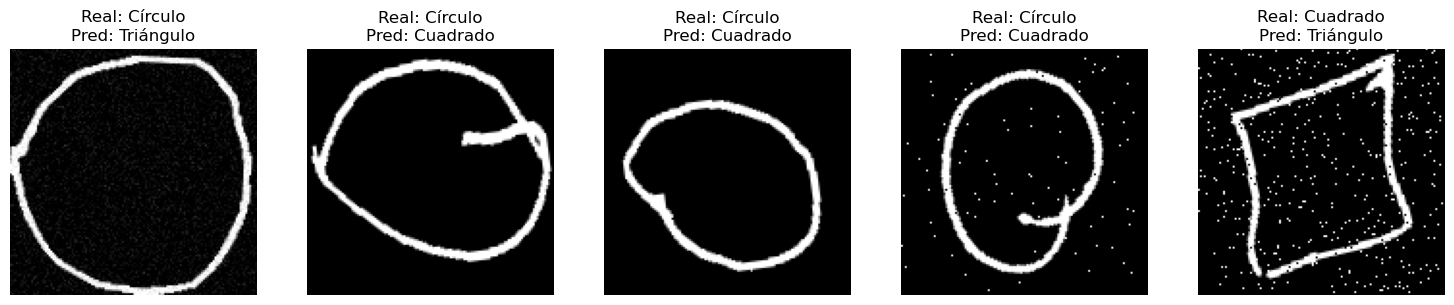


--- Formas confundidas por Momentos de Zernike ---


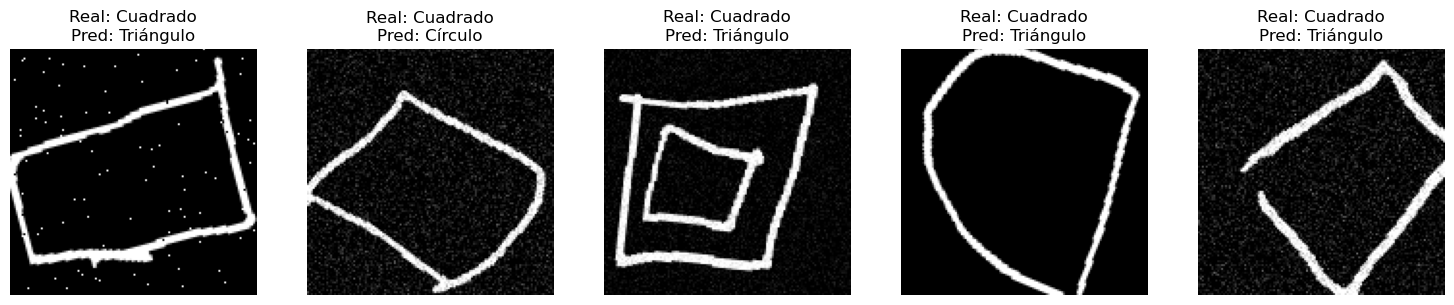


--- Formas confundidas por Shape Signature ---


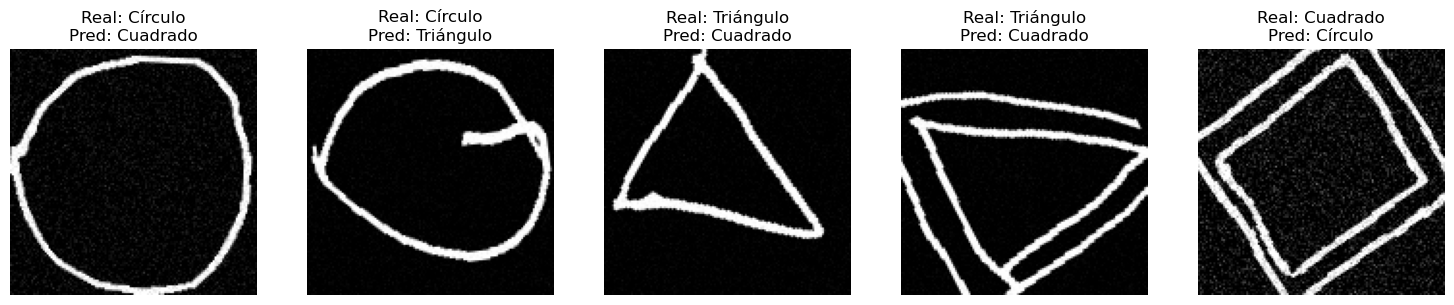

In [48]:
def show_confusions(y_true, y_pred, X_images, model_name, max_images=5):
    errores = np.where(y_true != y_pred)[0]
    if len(errores) == 0:
        print(f"No hay errores para {model_name}")
        return
    
    print(f"\n--- Formas confundidas por {model_name} ---")
    clases = ['Círculo', 'Triángulo', 'Cuadrado']
    n_images = min(max_images, len(errores))
    plt.figure(figsize=(15, 3))
    
    for i in range(n_images):
        idx = errores[i]
        plt.subplot(1, n_images, i+1)
        plt.imshow(X_images[idx], cmap='gray')
        plt.title(f"Real: {clases[y_true[idx]]}\nPred: {clases[y_pred[idx]]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_confusions(y_test, y_pred_hu, X_aug_test, "Momentos de Hu")
show_confusions(y_test, y_pred_z, X_aug_test, "Momentos de Zernike")
show_confusions(y_test, y_pred_shape, X_aug_test, "Shape Signature")

